In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
url = "https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt"
df = pd.read_csv(url, sep='\s+', skiprows=1)

In [3]:
df

,#,GRB_name,GRB_name_Fermi,T0,ra,decl,pos_error,T90,T90_error,T90_start,fluence,fluence_error,redshift,'T100',GBM_located,mjd,(T0)
0,#,(UTC),"(°,",J2000),"(°,",J2000),"(°,",1-sigma),(s),(s),(UTC),(erg/cm^2),(erg/cm^2),(s),(day),NaN,NaN
1,GRB260429A,GRB260429975,23:24:02,283.9000,18.1000,-999,0.1600,0.0360,23:24:02.001,2.3791e-06,2.0310e-08,-999,0.1610,False,61159.97502315,NaN,NaN
2,GRB260428A,GRB260428598,14:20:35,277.0000,1.9000,-999,3.9010,0.8590,14:20:35.686,4.3871e-04,3.4802e-04,-999,4.5870,False,61158.59762731,NaN,NaN
3,GRB260424B,NaN,23:37:22.824,348.1125,41.2290,-999,-999,-999,-999,-999,-999,-999,-999,False,61154.98429194,NaN,NaN
4,GRB260424A*,GRB260424646,15:30:22.373,171.7400,20.2400,10.315748,0.5760,0.2020,15:30:22.373,2.8315e-07,4.7466e-08,-999,0.5760,True,61154.64609228,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9086,GRB910425B*,NaN,5:33:13.716,335.9500,25.7667,4.790000,430.0160,1.0940,5:33:13.716,1.3510e-06,6.3429e-08,-999,430.0160,False,48371.23140875,NaN,NaN
9087,GRB910425A*,NaN,0:37:45.700,91.3000,-22.7667,1.020000,90.1760,0.2860,0:37:49.924,1.3277e-05,6.8674e-08,-999,94.4000,False,48371.02622338,NaN,NaN
9088,GRB910424A*,NaN,19:43:25.064,201.3000,-45.4167,13.780000,3.1360,0.5900,19:43:25.064,2.4858e-08,1.0496e-08,-999,3.1360,False,48370.82181787,NaN,NaN
9089,GRB910423A*,NaN,19:51:15.804,193.4750,-8.3833,11.100000,208.5760,1.1180,19:51:15.804,1.6510e-07,1.7015e-08,-999,208.5760,False,48369.82726625,NaN,NaN


In [4]:
df = df.drop(0)
df

,#,GRB_name,GRB_name_Fermi,T0,ra,decl,pos_error,T90,T90_error,T90_start,fluence,fluence_error,redshift,'T100',GBM_located,mjd,(T0)
1,GRB260429A,GRB260429975,23:24:02,283.9000,18.1000,-999,0.1600,0.0360,23:24:02.001,2.3791e-06,2.0310e-08,-999,0.1610,False,61159.97502315,NaN,NaN
2,GRB260428A,GRB260428598,14:20:35,277.0000,1.9000,-999,3.9010,0.8590,14:20:35.686,4.3871e-04,3.4802e-04,-999,4.5870,False,61158.59762731,NaN,NaN
3,GRB260424B,NaN,23:37:22.824,348.1125,41.2290,-999,-999,-999,-999,-999,-999,-999,-999,False,61154.98429194,NaN,NaN
4,GRB260424A*,GRB260424646,15:30:22.373,171.7400,20.2400,10.315748,0.5760,0.2020,15:30:22.373,2.8315e-07,4.7466e-08,-999,0.5760,True,61154.64609228,NaN,NaN
5,GRB260421C*,GRB260421351,8:25:18.055,294.9700,64.1500,3.003092,19.2000,1.1450,8:25:18.055,6.0902e-06,3.4637e-08,-999,19.2000,True,61151.35090341,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9086,GRB910425B*,NaN,5:33:13.716,335.9500,25.7667,4.790000,430.0160,1.0940,5:33:13.716,1.3510e-06,6.3429e-08,-999,430.0160,False,48371.23140875,NaN,NaN
9087,GRB910425A*,NaN,0:37:45.700,91.3000,-22.7667,1.020000,90.1760,0.2860,0:37:49.924,1.3277e-05,6.8674e-08,-999,94.4000,False,48371.02622338,NaN,NaN
9088,GRB910424A*,NaN,19:43:25.064,201.3000,-45.4167,13.780000,3.1360,0.5900,19:43:25.064,2.4858e-08,1.0496e-08,-999,3.1360,False,48370.82181787,NaN,NaN
9089,GRB910423A*,NaN,19:51:15.804,193.4750,-8.3833,11.100000,208.5760,1.1180,19:51:15.804,1.6510e-07,1.7015e-08,-999,208.5760,False,48369.82726625,NaN,NaN


In [5]:
cols = ['T90', 'fluence']
df = df[cols].dropna()
df

,T90,fluence
1,0.0360,2.0310e-08
2,0.8590,3.4802e-04
3,-999,-999
4,0.2020,4.7466e-08
5,1.1450,3.4637e-08
...,...,...
9086,1.0940,6.3429e-08
9087,0.2860,6.8674e-08
9088,0.5900,1.0496e-08
9089,1.1180,1.7015e-08


In [6]:
df['T90'] = pd.to_numeric(df['T90'], errors='coerce')
df['fluence'] = pd.to_numeric(df['fluence'], errors='coerce')

In [7]:
df = df.dropna(subset=['T90', 'fluence'])

In [8]:
df = df[(df['T90']>0) & (df['fluence']>0)]

In [9]:
df['T90'] = np.log10(df['T90'])
df['fluence'] = np.log10(df['fluence'])

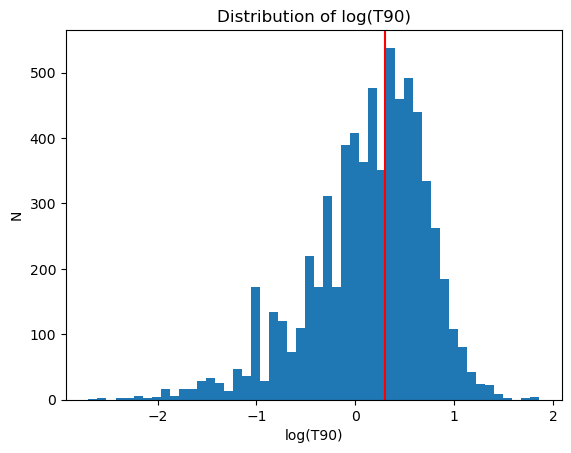

In [17]:
plt.hist(df['T90'], bins=50)
plt.title('Distribution of log(T90)')
plt.xlabel('log(T90)')
plt.ylabel('N')
plt.axvline(x=0.3, color='red')
plt.show()

In [12]:
scaler = StandardScaler()
X = scaler.fit_transform(df)

In [13]:
kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(X)

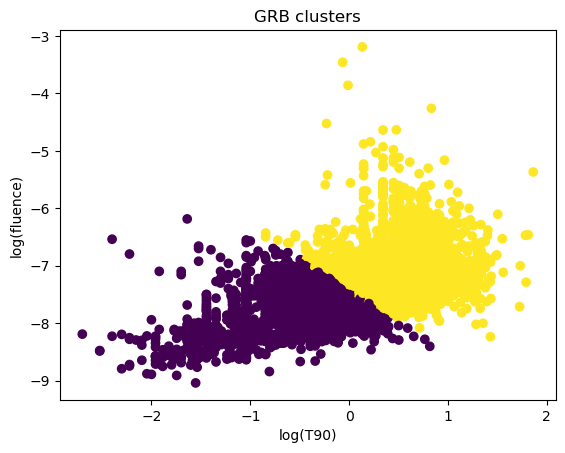

In [14]:
plt.scatter(df['T90'], df['fluence'], c=labels)
plt.xlabel('log(T90)')
plt.ylabel('log(fluence)')
plt.title('GRB clusters')
plt.show()

In [18]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2, random_state=0)
labels_gmm = gmm.fit_predict(X)

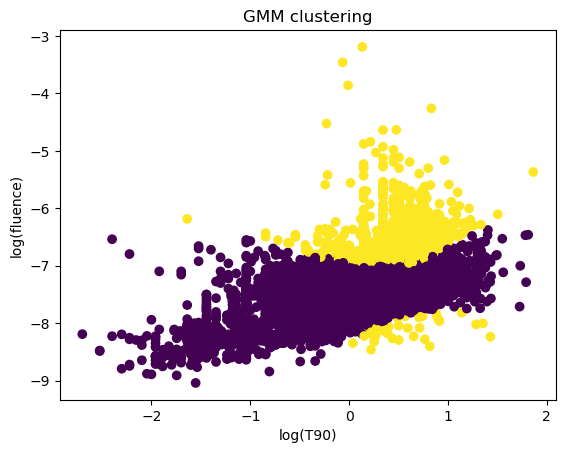

In [20]:
plt.scatter(df['T90'], df['fluence'], c=labels_gmm)
plt.title('GMM clustering')
plt.xlabel('log(T90)')
plt.ylabel('log(fluence)')
plt.show()

In [21]:
print("KMeans labels:", labels[:10])
print("GMM labels:", labels_gmm[:10])

KMeans labels: [0 1 0 1 1 0 0 1 1 0]
GMM labels: [0 1 0 0 0 0 0 0 0 0]


In [22]:
df_clean = df[
    (df['T90'] < df['T90'].quantile(0.99)) &
    (df['fluence'] < df['fluence'].quantile(0.99))
]

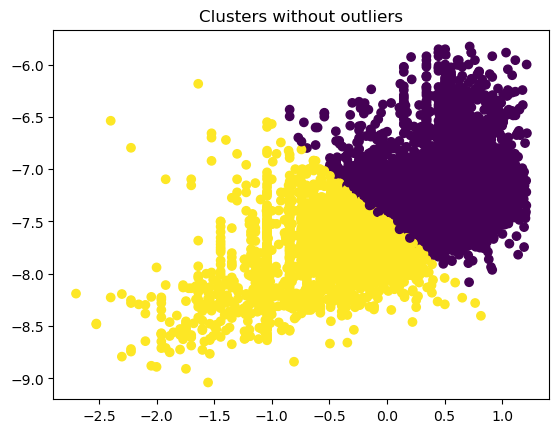

In [24]:
X_clean = scaler.fit_transform(df_clean)
kmeans_clean = KMeans(n_clusters=2, random_state=0)
labels_clean = kmeans_clean.fit_predict(X_clean)

plt.scatter(df_clean['T90'], df_clean['fluence'], c=labels_clean)
plt.title('Clusters without outliers')
plt.show()

In [25]:
print('original size:', len(df))
print('without outliers:', len(df_clean))

original size: 6764
without outliers: 6627


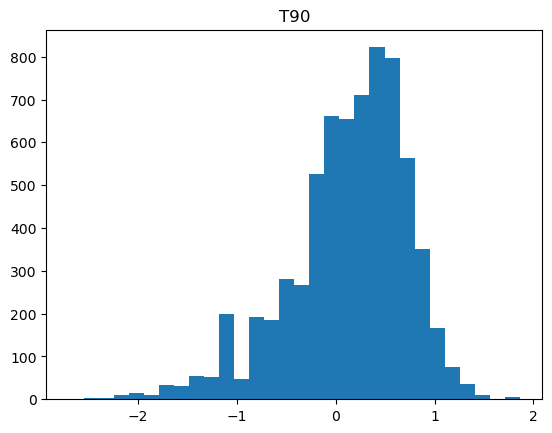

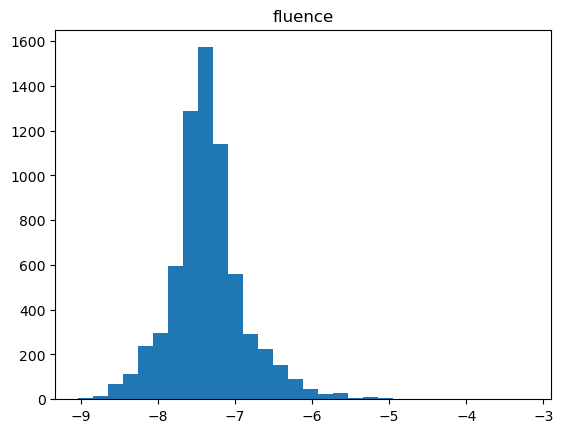

In [26]:
plt.hist(df['T90'], bins=30)
plt.title('T90')
plt.show()

plt.hist(df['fluence'], bins=30)
plt.title('fluence')
plt.show()

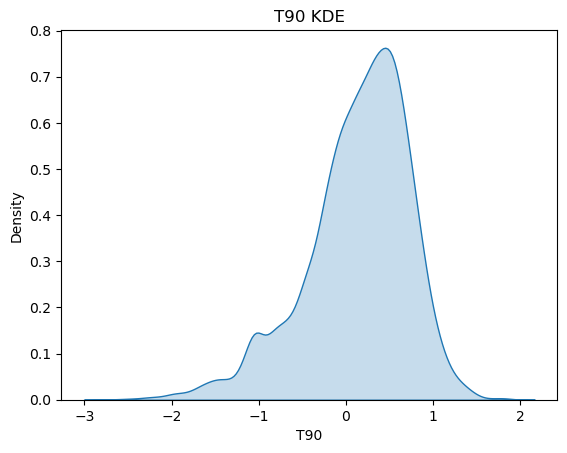

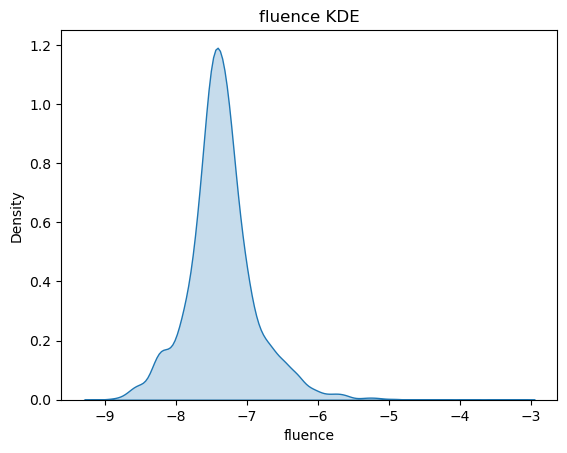

In [28]:
import seaborn as sns

sns.kdeplot(df["T90"], fill=True)
plt.title("T90 KDE")
plt.show()

sns.kdeplot(df["fluence"], fill=True)
plt.title("fluence KDE")
plt.show()

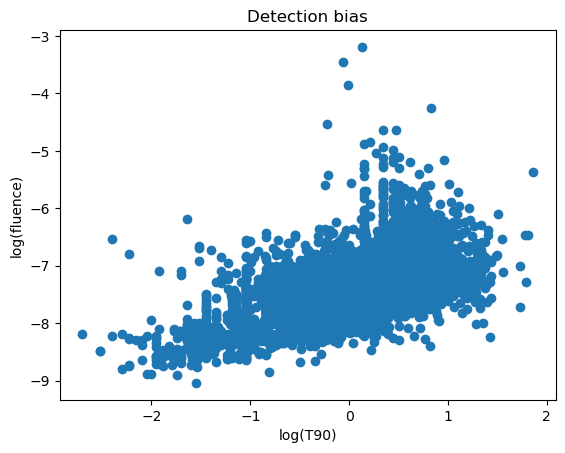

In [30]:
plt.scatter(df["T90"], df["fluence"])
plt.xlabel("log(T90)")
plt.ylabel("log(fluence)")
plt.title("Detection bias")
plt.show()

In [31]:
print("Fluence stats:")
print(df["fluence"].describe())

Fluence stats:
count    6764.000000
mean       -7.352109
std         0.489333
min        -9.039111
25%        -7.601912
50%        -7.384655
75%        -7.145576
max        -3.190642
Name: fluence, dtype: float64
